# Imports

In [1]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 12.49 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/Mercado-Artificial-Fiis


In [3]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [4]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [5]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

# Experimento

In [6]:
import os, sys, types, time, warnings, pickle, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from joblib import Parallel, delayed
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Setup ─────────────────────────────────────────────────────
os.chdir('/content/Mercado-Artificial-Fiis')

src_package = types.ModuleType('src')
src_package.__path__ = ['/content/Mercado-Artificial-Fiis/src']
src_package.__package__ = 'src'
sys.modules['src'] = src_package

for mod in list(sys.modules.keys()):
    if mod.startswith('src.'):
        del sys.modules[mod]

if '/content/Mercado-Artificial-Fiis' not in sys.path:
    sys.path.insert(0, '/content/Mercado-Artificial-Fiis')

from src.simulacao import simular_mercado_e_plotar, SIM_PARAMS
drive.mount('/content/drive', force_remount=False)

OUT_DIR = '/content/drive/MyDrive/tese_fii/choques'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

# ── Configurações ─────────────────────────────────────────────
THETA_STAR = parametros_sistema
DIA_CHOQUE = 61
T_TOTAL    = 121
VOL_JANELA = 20
N_REP      = 20
N_JOBS     = 2

# ── Persistência ──────────────────────────────────────────────
def salvar(obj, nome):
    path = f'{OUT_DIR}/{nome}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  ✓ Salvo: {path}')

def carregar(nome):
    path = f'{OUT_DIR}/{nome}.pkl'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print(f'  ✓ Carregado: {path}')
        return obj
    return None

# ── Simulador ─────────────────────────────────────────────────
def run_cenario(tipo, intensidade, duracao, delta, seed):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0
    params["choques"] = [
        {
            "categoria":   "noticia",
            "dia":         DIA_CHOQUE,
            "tipo":        tipo,
            "intensidade": intensidade,
            "duracao":     duracao,
            "delta":       delta,
        }
    ]

    r = simular_mercado_e_plotar(
        parametros_sistema=THETA_STAR,
        num_dias=T_TOTAL,
        sim_params=params,
        imprimir=False,
    )
    return (np.array(r[0])[-T_TOTAL:],
            np.array(r[1])[-(T_TOTAL - 1):],
            np.array(r[4], dtype=float))


def run_controle(seed):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0
    params["choques"] = []

    r = simular_mercado_e_plotar(
        parametros_sistema=THETA_STAR,
        num_dias=T_TOTAL,
        sim_params=params,
        imprimir=False,
    )
    return (np.array(r[0])[-T_TOTAL:],
            np.array(r[1])[-(T_TOTAL - 1):],
            np.array(r[4], dtype=float))


# ── Vol rolante ───────────────────────────────────────────────
def vol_rolante(retornos, janela=VOL_JANELA):
    vol = np.full(len(retornos), np.nan)
    for t in range(janela - 1, len(retornos)):
        vol[t] = np.std(retornos[t - janela + 1:t + 1])
    return vol


# ── Agregar ───────────────────────────────────────────────────
def agregar(lista_p, lista_r, lista_s):
    precos_norm = []
    for p in lista_p:
        if len(p) >= DIA_CHOQUE:
            ref = p[DIA_CHOQUE - 2]
            if ref > 0:
                precos_norm.append(p / ref)
    vols  = [vol_rolante(r) for r in lista_r if len(r) >= VOL_JANELA]
    sents = [s for s in lista_s if len(s) > 0]

    def stats(mat_list):
        mat = np.array(mat_list)
        m   = np.nanmean(mat, axis=0)
        se  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
        return m, m - 1.96 * se, m + 1.96 * se

    p_ = stats(precos_norm) if precos_norm else (None,) * 3
    v_ = stats(vols)        if vols        else (None,) * 3
    s_ = stats(sents)       if sents       else (None,) * 3
    return (*p_, *v_, *s_)


# ── Rodar cenário único ───────────────────────────────────────
def rodar_cenario_unico(c, prefixo):
    seeds = [
        abs(hash(f'{prefixo}_{c["tipo"]}_{c["intensidade"]}'
                 f'_{c["duracao"]}_{c["delta"]}_{r}')) % (2**31)
        for r in range(N_REP)
    ]
    res = Parallel(n_jobs=N_JOBS)(
        delayed(run_cenario)(
            c['tipo'], c['intensidade'],
            c['duracao'], c['delta'], s
        ) for s in seeds
    )
    agg = agregar([r[0] for r in res],
                  [r[1] for r in res],
                  [r[2] for r in res])
    print(f'  ✓ {c["label"]}')
    return (agg, c)



In [22]:
# ── Plot ──────────────────────────────────────────────────────
def plot_experimento(cenarios, controle_agg, titulo, fname, cores=None):
    if cores is None:
        cores = plt.cm.tab10(np.linspace(0, 0.8, len(cenarios)))

    dias_p = np.arange(1, T_TOTAL + 1)
    dias_r = np.arange(1, T_TOTAL)

    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])

    cp, cp_lo, cp_hi, cv, cv_lo, cv_hi, cs, cs_lo, cs_hi = controle_agg

    if cp is not None:
        ax1.fill_between(dias_p, cp_lo, cp_hi, color='gray',
                         alpha=0.15, label='Controle (IC 95%)')
        ax1.plot(dias_p, cp, color='gray', lw=1.2, ls='--', alpha=0.6)
    if cv is not None:
        ax2.fill_between(dias_r, cv_lo, cv_hi, color='gray', alpha=0.15)
        ax2.plot(dias_r, cv, color='gray', lw=1.2, ls='--', alpha=0.6)
    if cs is not None:
        ax3.fill_between(np.arange(1,len(cs)+1), cs_lo, cs_hi,
                         color='gray', alpha=0.15)
        ax3.plot(np.arange(1,len(cs)+1), cs, color='gray',
                 lw=1.2, ls='--', alpha=0.6)

    for (agg, meta), cor in zip(cenarios, cores):
        p, p_lo, p_hi, v, v_lo, v_hi, s, s_lo, s_hi = agg
        label = meta['label']
        if p is not None:
            ax1.fill_between(dias_p, p_lo, p_hi, color=cor, alpha=0.10)
            ax1.plot(dias_p, p, color=cor, lw=2, label=label)
        if v is not None:
            ax2.fill_between(dias_r, v_lo, v_hi, color=cor, alpha=0.10)
            ax2.plot(dias_r, v, color=cor, lw=2, label=label)
        if s is not None:
            ax3.fill_between(np.arange(1,len(s)+1), s_lo, s_hi,
                             color=cor, alpha=0.10)
            ax3.plot(np.arange(1,len(s)+1), s, color=cor, lw=2, label=label)

    for ax in [ax1, ax2, ax3]:
        ax.axvline(DIA_CHOQUE, color='red', lw=1.5, ls='--', alpha=0.7,
                   label='Choque' if ax == ax1 else '')
        ax.grid(True, alpha=0.2, ls=':')

    ax1.axhline(1.0, color='black', lw=0.8, ls=':', alpha=0.5)
    ax3.axhline(0.0, color='black', lw=0.8, ls=':', alpha=0.5)
    ax1.set_ylabel('Preço normalizado\n(P / P anterior ao choque)', fontsize=10)
    ax2.set_ylabel(f'Volatilidade rolante\n({VOL_JANELA} dias)', fontsize=10)
    ax3.set_ylabel('Sentimento médio\nda população', fontsize=10)
    ax3.set_xlabel('Dia de simulação', fontsize=10)
    ax3.set_ylim(-1.1, 1.1)
    ax1.legend(fontsize=8, loc='lower left')
    ax2.legend(fontsize=8, loc='upper left')
    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.01)

    path = f'{FIG_DIR}/{fname}'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  ✓ Figura: {path}')


print('✓ Funções carregadas')
print(f'  OUT_DIR: {OUT_DIR}')
print(f'  N_REP={N_REP} | N_JOBS={N_JOBS} | T={T_TOTAL} | Choque dia {DIA_CHOQUE}')


✓ Funções carregadas
  OUT_DIR: /content/drive/MyDrive/tese_fii/choques
  N_REP=20 | N_JOBS=2 | T=121 | Choque dia 61


In [9]:
# ══════════════════════════════════════════════════════════════
# CONTROLE
# ══════════════════════════════════════════════════════════════
print('── Controle ──────────────────────────────────────────')
controle_agg = carregar('controle_agg')

if controle_agg is None:
    print('Rodando controle...')
    t0    = time.time()
    seeds = [abs(hash(f'ctrl_{r}')) % (2**31) for r in range(N_REP)]
    res   = Parallel(n_jobs=N_JOBS)(
        delayed(run_controle)(s) for s in seeds
    )
    controle_agg = agregar([r[0] for r in res],
                           [r[1] for r in res],
                           [r[2] for r in res])
    salvar(controle_agg, 'controle_agg')
    print(f'  Tempo: {(time.time() - t0) / 60:.1f} min')

── Controle ──────────────────────────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/controle_agg.pkl



── Experimento 1 — Tipo do choque ────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp1_tipo.pkl


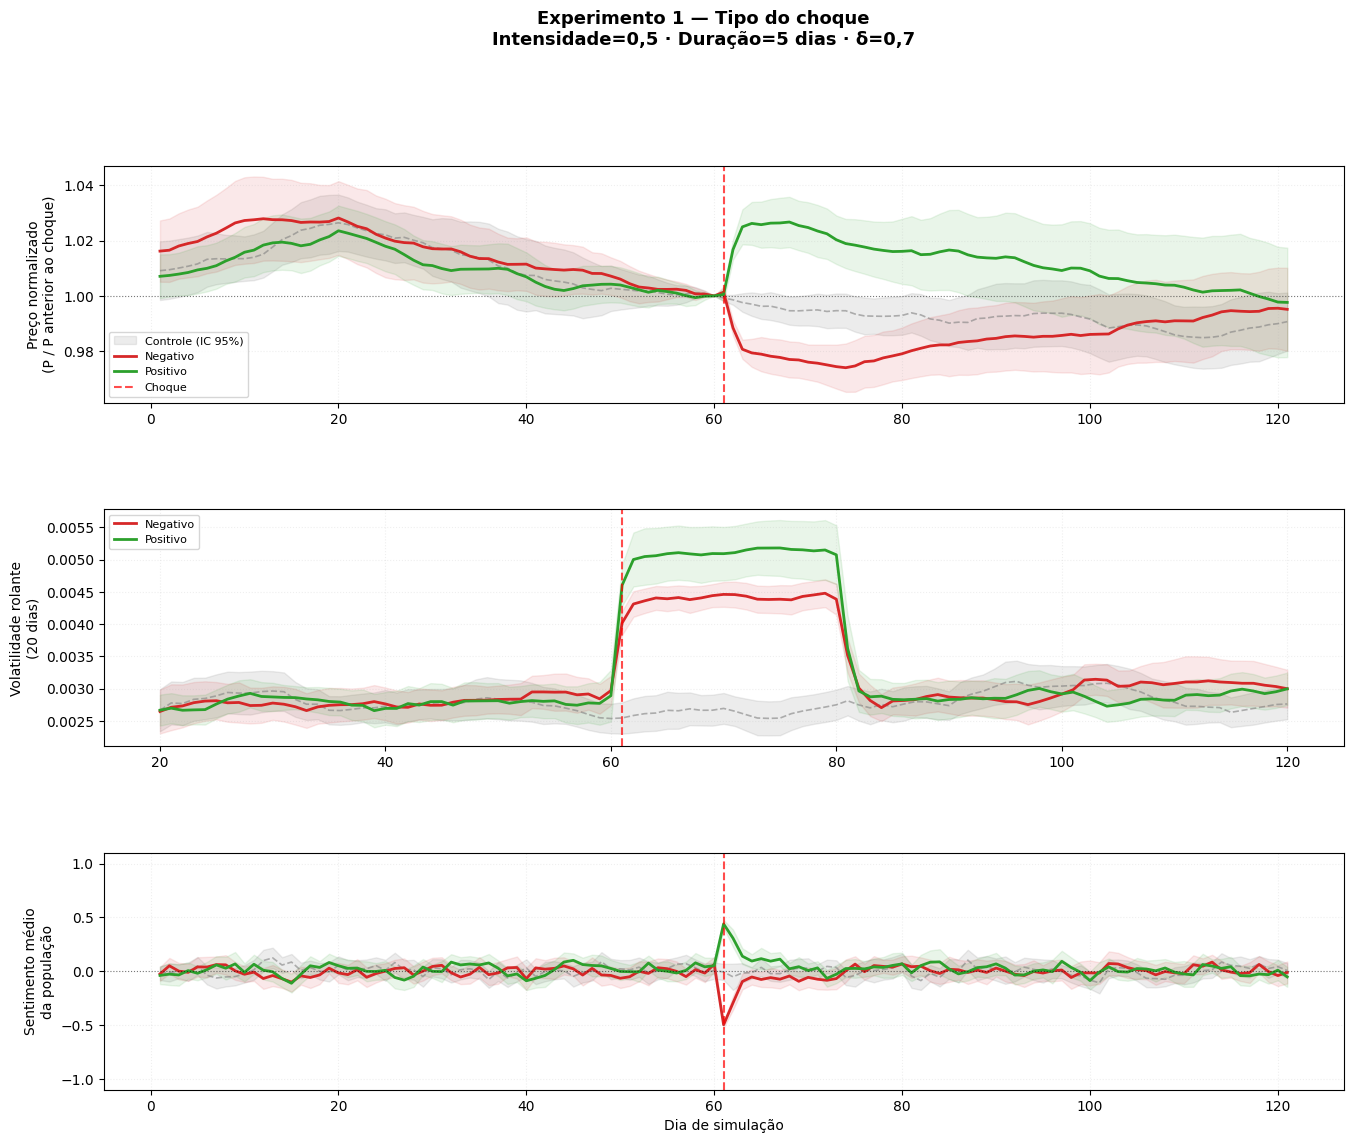

  ✓ Figura: /content/drive/MyDrive/tese_fii/choques/figures/exp1_tipo.png


In [23]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO 1 — TIPO DO CHOQUE
# ══════════════════════════════════════════════════════════════
print('\n── Experimento 1 — Tipo do choque ────────────────────')
exp1 = carregar('exp1_tipo')

if exp1 is None:
    t0   = time.time()
    exp1 = []
    for c in [
        dict(tipo='negativo', intensidade=0.5, duracao=5,
             delta=0.7, label='Negativo'),
        dict(tipo='positivo', intensidade=0.5, duracao=5,
             delta=0.7, label='Positivo'),
    ]:
        exp1.append(rodar_cenario_unico(c, 'exp1'))
    salvar(exp1, 'exp1_tipo')
    print(f'  Tempo total: {(time.time() - t0) / 60:.1f} min')

plot_experimento(
    exp1, controle_agg,
    titulo=('Experimento 1 — Tipo do choque\n'
            'Intensidade=0,5 · Duração=5 dias · δ=0,7'),
    fname='exp1_tipo.png',
    cores=['#d62728', '#2ca02c'],
)

In [11]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO 1 — RESUMO NUMÉRICO (extraído das simulações já rodadas)
# ══════════════════════════════════════════════════════════════
import numpy as np

cp_lo, cp_hi = controle_agg[1], controle_agg[2]
cv_ctrl  = controle_agg[3]
vol_base = cv_ctrl[20:DIA_CHOQUE]
vol_base = vol_base[~np.isnan(vol_base)].mean()
limiar   = vol_base * 1.10

def resumo_tipo(agg):
    p, p_lo, p_hi, v, v_lo, v_hi, s, s_lo, s_hi = agg
    pos = slice(DIA_CHOQUE, None)
    dev = p[pos] - 1.0
    idx = int(np.nanargmax(np.abs(dev)))          # dia de maior afastamento de 1
    pico_preco = dev[idx] * 100                    # % com sinal
    p_final    = (p[-20:].mean() - 1.0) * 100
    sd = s[pos]
    sent_ext = sd[int(np.nanargmax(np.abs(sd)))]   # extremo do sentimento, com sinal
    vv = v[pos][~np.isnan(v[pos])]
    pico_vol = vv.max() if len(vv) else np.nan
    dias_vol = int(np.sum(vv > limiar)) if len(vv) else 0
    permanencia = (p[-20:].mean() - 1.0) / dev[idx] if dev[idx] != 0 else np.nan
    return dict(pico_preco=pico_preco, dia_pico=DIA_CHOQUE + idx, p_final=p_final,
                sent_ext=sent_ext, pico_vol=pico_vol, dias_vol=dias_vol,
                permanencia=permanencia)

res = {meta['tipo']: resumo_tipo(agg) for (agg, meta) in exp1}

print(f'{"Tipo":10} {"Pico preço (%)":>15} {"Dia pico":>9} {"P̄ final (%)":>12} '
      f'{"Sent. extremo":>14} {"Pico vol":>10} {"Dias vol>base":>14} {"Permanência":>12}')
for tipo in ['positivo', 'negativo']:
    if tipo in res:
        r = res[tipo]
        print(f'{tipo:10} {r["pico_preco"]:>15.2f} {r["dia_pico"]:>9} {r["p_final"]:>12.2f} '
              f'{r["sent_ext"]:>14.4f} {r["pico_vol"]:>10.5f} {r["dias_vol"]:>14} {r["permanencia"]:>12.2f}')

if 'positivo' in res and 'negativo' in res:
    rp, rn = res['positivo'], res['negativo']
    print('\n── Assimetria (magnitude positiva / magnitude negativa) ──')
    print(f'  Preço:      {abs(rp["pico_preco"])/abs(rn["pico_preco"]):.2f}')
    print(f'  Sentimento: {abs(rp["sent_ext"])/abs(rn["sent_ext"]):.2f}')

def janela_signif(p_lo, p_hi):
    dias = [t for t in range(DIA_CHOQUE, len(p_lo))
            if not (np.isnan(p_lo[t]) or np.isnan(cp_lo[t]))
            and (p_lo[t] > cp_hi[t] or p_hi[t] < cp_lo[t])]
    return (dias[0], dias[-1], len(dias)) if dias else None

print('\n── Janela de significância no preço (dia inicial, final, nº de dias) ──')
for (agg, meta) in exp1:
    print(f'  {meta["tipo"]:10}: {janela_signif(agg[1], agg[2])}')

Tipo        Pico preço (%)  Dia pico P̄ final (%)  Sent. extremo   Pico vol  Dias vol>base  Permanência
positivo              2.67        67         0.25         0.3073    0.00518             20         0.09
negativo             -2.60        73        -0.79        -0.2938    0.00448             35         0.30

── Assimetria (magnitude positiva / magnitude negativa) ──
  Preço:      1.03
  Sentimento: 1.05

── Janela de significância no preço (dia inicial, final, nº de dias) ──
  negativo  : (61, 76, 16)
  positivo  : (61, 85, 25)


In [12]:
import numpy as np
cs = controle_agg[6]  # sentimento do controle

print('── Tamanho das séries ──')
for (agg, meta) in exp1:
    print(f'  {meta["tipo"]:9} | len preço={len(agg[0])}  len sentimento={len(agg[6])}')

def sent_extremo(s, cs):
    s  = np.asarray(s)[-T_TOTAL:]          # alinha pelo fim, igual ao preço
    cs = np.asarray(cs)[-T_TOTAL:]
    pos = slice(DIA_CHOQUE, None)
    bruto = s[pos]
    dev   = (s - cs)[pos]                   # desvio em relação ao controle
    ib = int(np.nanargmax(np.abs(bruto)))
    idv = int(np.nanargmax(np.abs(dev)))
    return bruto[ib], DIA_CHOQUE + ib, dev[idv], DIA_CHOQUE + idv

print('\ntipo      | s_ext(bruto) dia | s_ext(vs controle) dia')
for (agg, meta) in exp1:
    b, db, d, dd = sent_extremo(agg[6], cs)
    print(f'  {meta["tipo"]:9} | {b:>10.4f} {db:>4} | {d:>12.4f} {dd:>4}')

── Tamanho das séries ──
  negativo  | len preço=121  len sentimento=121
  positivo  | len preço=121  len sentimento=121

tipo      | s_ext(bruto) dia | s_ext(vs controle) dia
  negativo  |    -0.2938   61 |      -0.2422   61
  positivo  |     0.3073   61 |       0.3590   61


In [13]:
import numpy as np
cp, cv, cs = controle_agg[0], controle_agg[3], controle_agg[6]
pos = slice(DIA_CHOQUE, None)

def resumo(agg):
    p, v, s = agg[0], agg[3], agg[6]
    dp = (p - cp)[pos];  ip  = int(np.nanargmax(np.abs(dp)))
    ds = (s - cs)[pos];  isx = int(np.nanargmax(np.abs(ds)))
    dv = (v - cv)[pos];  dv  = dv[~np.isnan(dv)]
    pfinal = (p[-20:].mean() - cp[-20:].mean()) * 100
    perm   = (pfinal / 100) / dp[ip] if dp[ip] else np.nan
    return dict(pico_preco=dp[ip]*100, pfinal=pfinal, perm=perm,
                sent=ds[isx], pico_vol=(dv.max() if len(dv) else np.nan))

R = {m['tipo']: resumo(a) for a, m in exp1}
for t in ['positivo', 'negativo']:
    x = R[t]
    print(f'{t:9} pico_preço={x["pico_preco"]:>6.2f}%  P̄final={x["pfinal"]:>6.2f}%  '
          f'perm={x["perm"]:>5.2f}  sent={x["sent"]:>7.4f}  picovol_vs_ctrl={x["pico_vol"]:.5f}')
print(f'\nAssimetria vs controle | preço={abs(R["positivo"]["pico_preco"])/abs(R["negativo"]["pico_preco"]):.2f}  '
      f'sentimento={abs(R["positivo"]["sent"])/abs(R["negativo"]["sent"]):.2f}')

positivo  pico_preço=  3.21%  P̄final=  1.48%  perm= 0.46  sent= 0.3590  picovol_vs_ctrl=0.00264
negativo  pico_preço= -2.06%  P̄final=  0.44%  perm=-0.21  sent=-0.2422  picovol_vs_ctrl=0.00184

Assimetria vs controle | preço=1.56  sentimento=1.48


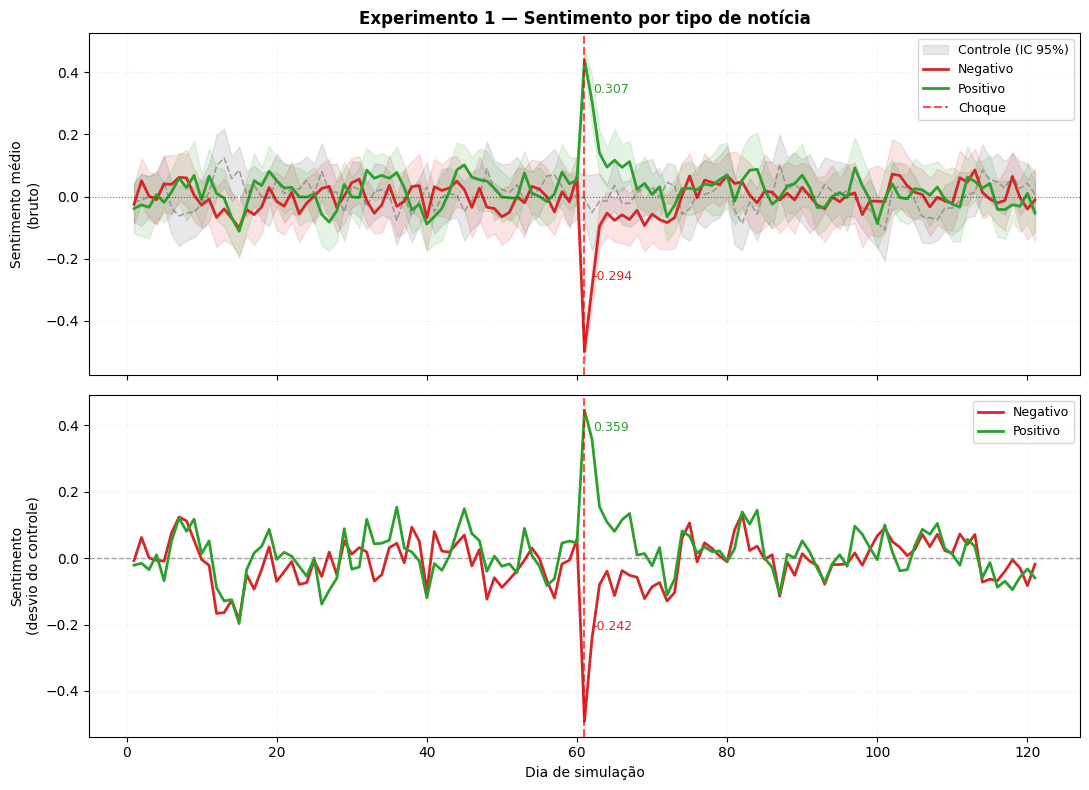

In [14]:
import numpy as np
import matplotlib.pyplot as plt

dias = np.arange(1, T_TOTAL + 1)
cs, cs_lo, cs_hi = controle_agg[6], controle_agg[7], controle_agg[8]
cores = {'positivo': '#2ca02c', 'negativo': '#d62728'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# ── Painel 1: sentimento bruto com banda do controle ──
ax1.fill_between(dias, cs_lo, cs_hi, color='gray', alpha=0.18, label='Controle (IC 95%)')
ax1.plot(dias, cs, color='gray', lw=1.2, ls='--', alpha=0.7)
for (agg, meta) in exp1:
    s, s_lo, s_hi = agg[6], agg[7], agg[8]
    c = cores.get(meta['tipo'], 'black')
    ax1.fill_between(dias, s_lo, s_hi, color=c, alpha=0.12)
    ax1.plot(dias, s, color=c, lw=2, label=meta['tipo'].capitalize())
    ext = s[DIA_CHOQUE:]; i = int(np.nanargmax(np.abs(ext)))
    ax1.annotate(f'{ext[i]:.3f}', (DIA_CHOQUE + i, ext[i]),
                 textcoords='offset points', xytext=(6, 6), color=c, fontsize=9)
ax1.axvline(DIA_CHOQUE, color='red', lw=1.5, ls='--', alpha=0.7, label='Choque')
ax1.axhline(0.0, color='black', lw=0.8, ls=':', alpha=0.5)
ax1.set_ylabel('Sentimento médio\n(bruto)')
ax1.set_title('Experimento 1 — Sentimento por tipo de notícia', fontweight='bold')
ax1.legend(fontsize=9, loc='best'); ax1.grid(True, alpha=0.2, ls=':')

# ── Painel 2: desvio em relação ao controle ──
ax2.axhline(0.0, color='gray', lw=1.0, ls='--', alpha=0.7)
for (agg, meta) in exp1:
    dev = agg[6] - cs
    c = cores.get(meta['tipo'], 'black')
    ax2.plot(dias, dev, color=c, lw=2, label=meta['tipo'].capitalize())
    d = dev[DIA_CHOQUE:]; i = int(np.nanargmax(np.abs(d)))
    ax2.annotate(f'{d[i]:.3f}', (DIA_CHOQUE + i, d[i]),
                 textcoords='offset points', xytext=(6, 6), color=c, fontsize=9)
ax2.axvline(DIA_CHOQUE, color='red', lw=1.5, ls='--', alpha=0.7)
ax2.set_ylabel('Sentimento\n(desvio do controle)')
ax2.set_xlabel('Dia de simulação')
ax2.legend(fontsize=9, loc='best'); ax2.grid(True, alpha=0.2, ls=':')

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
cp, cv, cs = controle_agg[0], controle_agg[3], controle_agg[6]
pos = slice(DIA_CHOQUE - 1, None)   # começa no dia do choque (índice 60)

def resumo(agg):
    p, v, s = agg[0], agg[3], agg[6]
    dp = (p - cp)[pos]; ip  = int(np.nanargmax(np.abs(dp)))
    ds = (s - cs)[pos]; isx = int(np.nanargmax(np.abs(ds)))
    dv = (v - cv)[pos]; mask = ~np.isnan(dv)
    pfinal = (p[-20:].mean() - cp[-20:].mean()) * 100
    perm   = (pfinal / 100) / dp[ip] if dp[ip] else np.nan
    return dict(pico_preco=dp[ip]*100, dia_preco=(DIA_CHOQUE-1)+ip,
                pfinal=pfinal, perm=perm,
                sent=ds[isx], dia_sent=(DIA_CHOQUE-1)+isx,
                pico_vol=(dv[mask].max() if mask.any() else np.nan))

R = {m['tipo']: resumo(a) for a, m in exp1}
for t in ['positivo', 'negativo']:
    x = R[t]
    print(f'{t:9} pico_preço={x["pico_preco"]:>6.2f}% (dia {x["dia_preco"]})  '
          f'P̄final={x["pfinal"]:>6.2f}%  perm={x["perm"]:>5.2f}  '
          f'sent={x["sent"]:>7.4f} (dia {x["dia_sent"]})  picovol={x["pico_vol"]:.5f}')
print(f'\nAssimetria vs controle | '
      f'preço={abs(R["positivo"]["pico_preco"])/abs(R["negativo"]["pico_preco"]):.2f}  '
      f'sentimento(pos/neg)={abs(R["positivo"]["sent"])/abs(R["negativo"]["sent"]):.2f}')

positivo  pico_preço=  3.21% (dia 67)  P̄final=  1.48%  perm= 0.46  sent= 0.4459 (dia 60)  picovol=0.00264
negativo  pico_preço= -2.06% (dia 73)  P̄final=  0.44%  perm=-0.21  sent=-0.4911 (dia 60)  picovol=0.00184

Assimetria vs controle | preço=1.56  sentimento(pos/neg)=0.91


## Experimento 02


── Experimento 2 — Intensidade ───────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp2_int_0_1.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp2_int_0_25.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp2_int_0_5.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp2_int_0_75.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp2_int_0_95.pkl
  ✓ Salvo: /content/drive/MyDrive/tese_fii/choques/exp2_intensidade.pkl
  Tempo total: 0.0 min


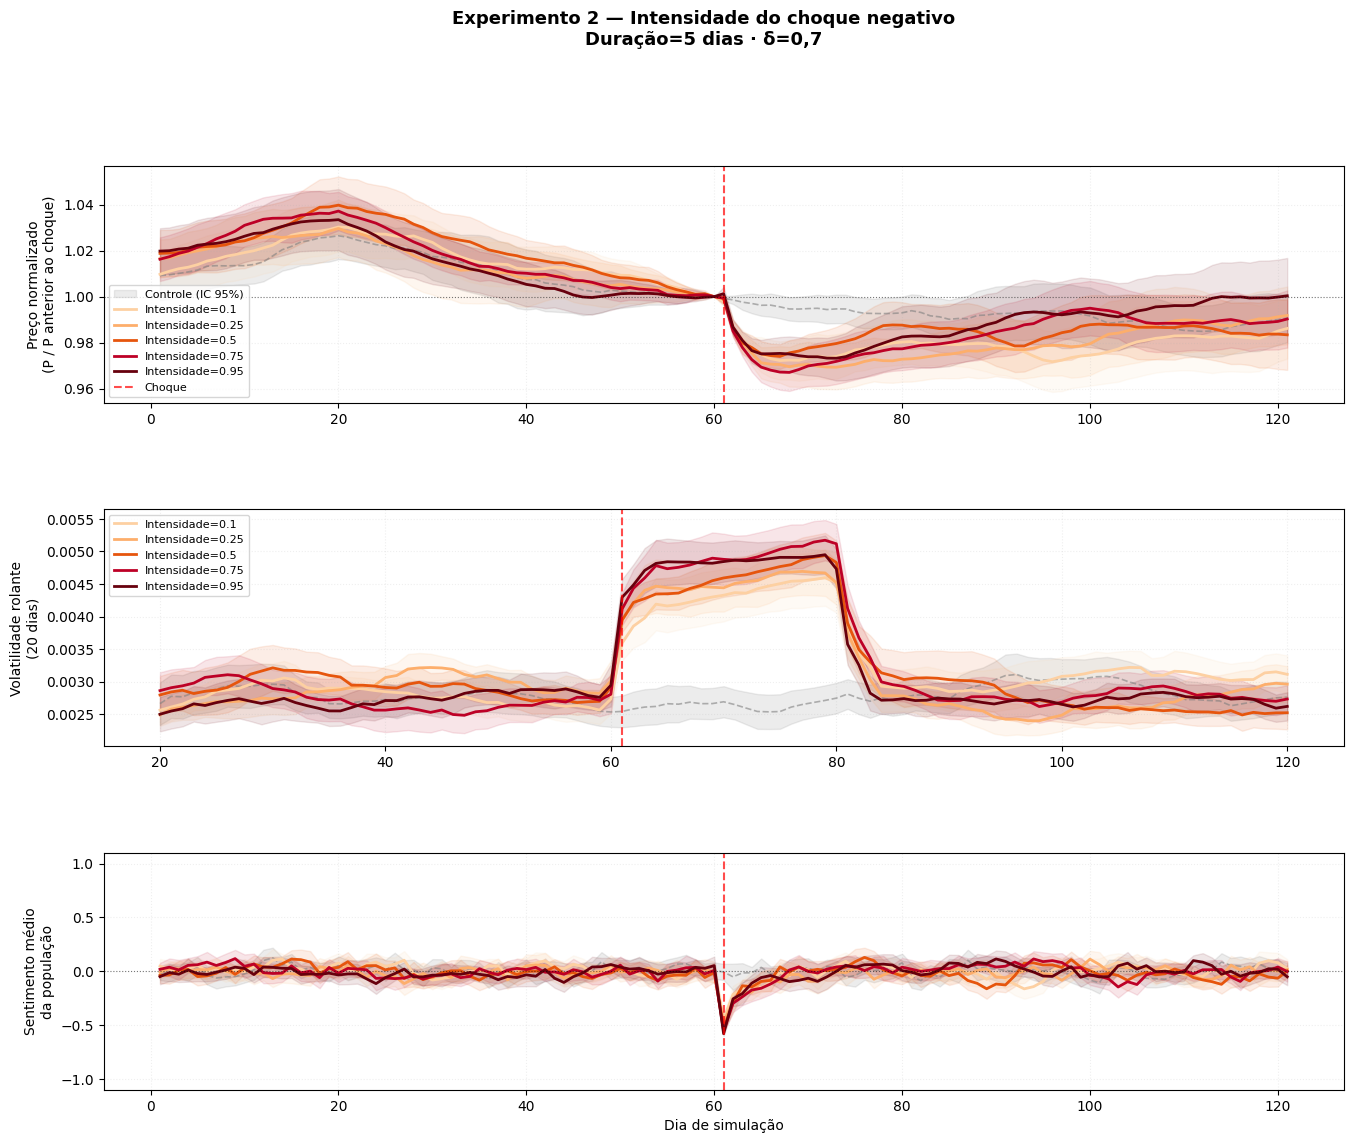

  ✓ Figura: /content/drive/MyDrive/tese_fii/choques/figures/exp2_intensidade.png

 Intensidade |  Queda máx (%) |  P̄ dias 100-121 (%) |   Pico vol | Vol baseline |  Sent. mín
----------------------------------------------------------------------------------
        0.10 |          -2.83 |                -1.81 |    0.00460 |      0.00277 |    -0.2149
        0.25 |          -3.07 |                -1.17 |    0.00469 |      0.00277 |    -0.2812
        0.50 |          -2.60 |                -1.43 |    0.00494 |      0.00277 |    -0.2954
        0.75 |          -3.30 |                -1.05 |    0.00517 |      0.00277 |    -0.2979
        0.95 |          -2.68 |                -0.31 |    0.00495 |      0.00277 |    -0.2563


In [24]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO 2 — INTENSIDADE DO CHOQUE
# ══════════════════════════════════════════════════════════════
print('\n── Experimento 2 — Intensidade ───────────────────────')

INTENSIDADES = [0.10, 0.25, 0.50, 0.75, 0.95]
CORES_INT    = ['#fdd0a2', '#fdae6b', '#e6550d', '#bd0026', '#67000d']

exp2     = []
t0_total = time.time()

for intens in INTENSIDADES:
    nome_cache = f'exp2_int_{str(intens).replace(".", "_")}'
    resultado  = carregar(nome_cache)

    if resultado is None:
        t0 = time.time()
        c  = dict(tipo='negativo', intensidade=intens,
                  duracao=5, delta=0.7,
                  label=f'Intensidade={intens}')
        resultado = rodar_cenario_unico(c, 'exp2')
        salvar(resultado, nome_cache)
        print(f'    Tempo: {(time.time() - t0) / 60:.1f} min')

    exp2.append(resultado)

salvar(exp2, 'exp2_intensidade')
print(f'  Tempo total: {(time.time() - t0_total) / 60:.1f} min')

plot_experimento(
    exp2, controle_agg,
    titulo=('Experimento 2 — Intensidade do choque negativo\n'
            'Duração=5 dias · δ=0,7'),
    fname='exp2_intensidade.png',
    cores=CORES_INT,
)

# ── Tabela resumo Exp 2 ───────────────────────────────────────
print(f'\n{"Intensidade":>12} | {"Queda máx (%)":>14} | '
      f'{"P̄ dias 100-121 (%)":>20} | '
      f'{"Pico vol":>10} | {"Vol baseline":>12} | '
      f'{"Sent. mín":>10}')
print('-' * 82)

cv_ctrl  = controle_agg[3]
vol_base = cv_ctrl[20:DIA_CHOQUE]
vol_base = vol_base[~np.isnan(vol_base)].mean()

for (agg, meta) in exp2:
    intens    = meta['intensidade']
    p, v, s   = agg[0], agg[3], agg[6]
    if p is None: continue
    p_pos     = p[DIA_CHOQUE:]
    queda_max = (p_pos.min() - 1.0) * 100
    p_final   = (p[-20:].mean() - 1.0) * 100
    v_pos_c   = v[DIA_CHOQUE:][~np.isnan(v[DIA_CHOQUE:])] if v is not None else np.array([])
    pico_vol  = v_pos_c.max() if len(v_pos_c) > 0 else np.nan
    sent_min  = s[DIA_CHOQUE:].min() if s is not None else np.nan
    print(f'{intens:>12.2f} | {queda_max:>14.2f} | {p_final:>20.2f} | '
          f'{pico_vol:>10.5f} | {vol_base:>12.5f} | {sent_min:>10.4f}')


── Experimento 3 — Duração ───────────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp3_dur_1.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp3_dur_10.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp3_dur_20.pkl
  ✓ Salvo: /content/drive/MyDrive/tese_fii/choques/exp3_duracao.pkl
  Tempo total: 0.0 min


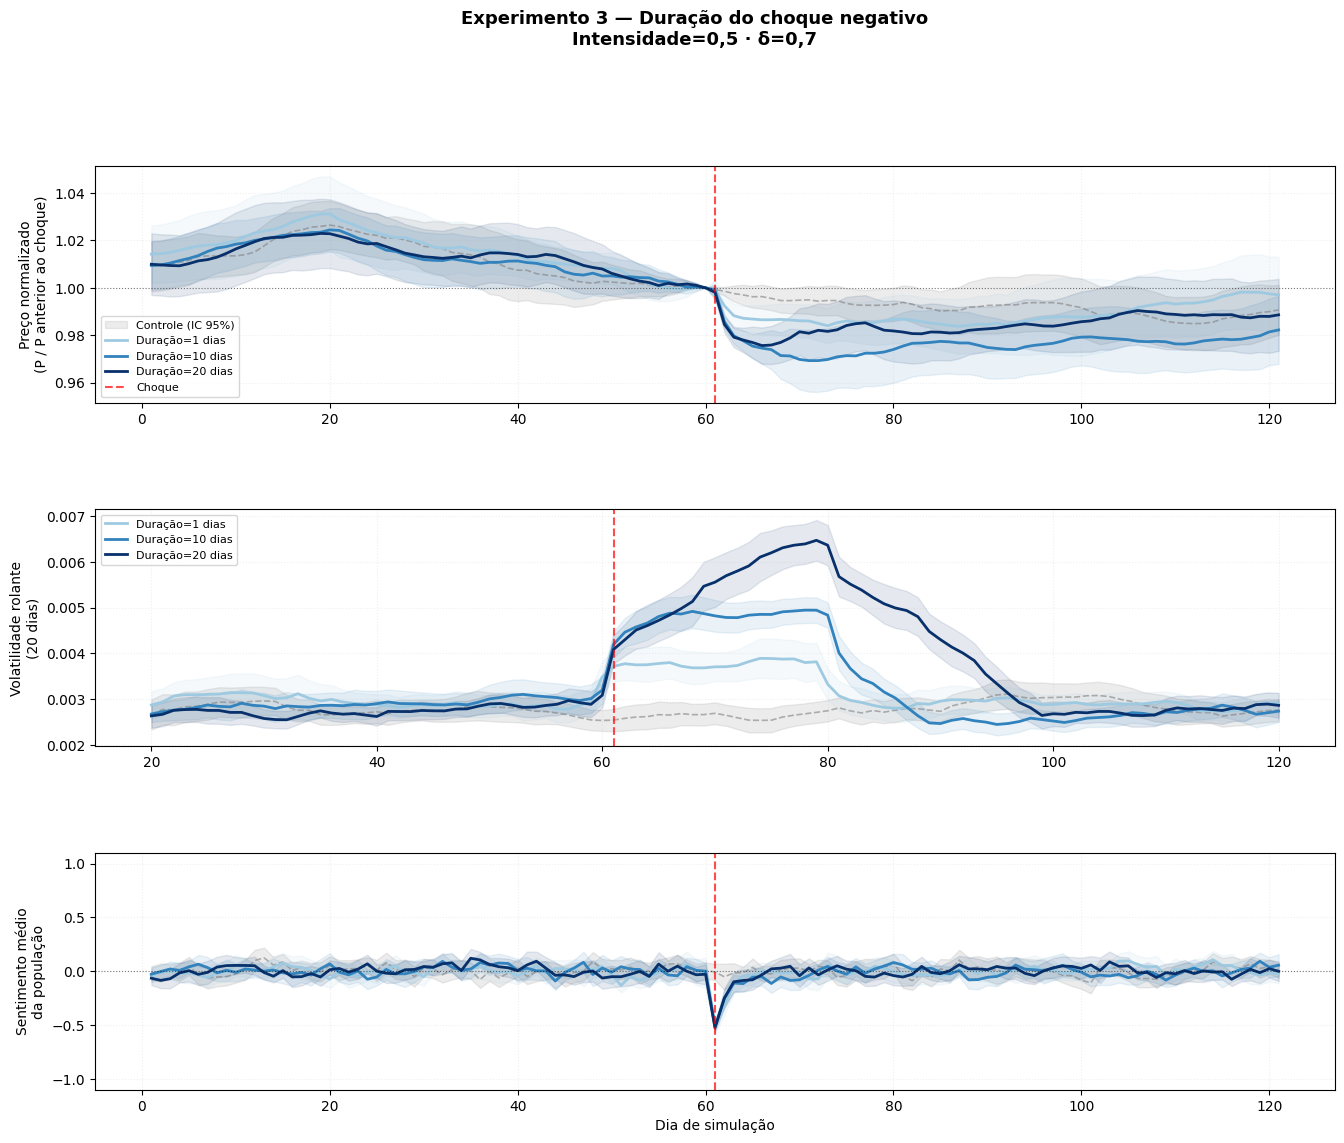

  ✓ Figura: /content/drive/MyDrive/tese_fii/choques/figures/exp3_duracao.png

 Duração |  Queda máx (%) |  P̄ dias 100-121 (%) |   Pico vol | Dias vol>base |  Sent. mín
-------------------------------------------------------------------------------------
       1 |          -1.62 |                -0.61 |    0.00389 |            20 |    -0.3237
      10 |          -3.07 |                -2.17 |    0.00495 |            24 |    -0.2543
      20 |          -2.43 |                -1.14 |    0.00647 |            35 |    -0.2479


In [25]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO 3 — DURAÇÃO DO CHOQUE
# ══════════════════════════════════════════════════════════════
print('\n── Experimento 3 — Duração ───────────────────────────')

DURACOES  = [1, 10, 20]
CORES_DUR = ['#9ecae1', '#3182bd', '#08306b']

exp3     = []
t0_total = time.time()

for dur in DURACOES:
    nome_cache = f'exp3_dur_{dur}'
    resultado  = carregar(nome_cache)

    if resultado is None:
        t0 = time.time()
        c  = dict(tipo='negativo', intensidade=0.5,
                  duracao=dur, delta=0.7,
                  label=f'Duração={dur} dias')
        resultado = rodar_cenario_unico(c, 'exp3')
        salvar(resultado, nome_cache)
        print(f'    Tempo: {(time.time() - t0) / 60:.1f} min')

    exp3.append(resultado)

salvar(exp3, 'exp3_duracao')
print(f'  Tempo total: {(time.time() - t0_total) / 60:.1f} min')

plot_experimento(
    exp3, controle_agg,
    titulo=('Experimento 3 — Duração do choque negativo\n'
            'Intensidade=0,5 · δ=0,7'),
    fname='exp3_duracao.png',
    cores=CORES_DUR,
)

# ── Tabela resumo Exp 3 ───────────────────────────────────────
print(f'\n{"Duração":>8} | {"Queda máx (%)":>14} | '
      f'{"P̄ dias 100-121 (%)":>20} | '
      f'{"Pico vol":>10} | {"Dias vol>base":>13} | '
      f'{"Sent. mín":>10}')
print('-' * 85)

limiar = vol_base * 1.10
for (agg, meta) in exp3:
    dur     = meta['duracao']
    p, v, s = agg[0], agg[3], agg[6]
    if p is None: continue
    p_pos     = p[DIA_CHOQUE:]
    queda_max = (p_pos.min() - 1.0) * 100
    p_final   = (p[-20:].mean() - 1.0) * 100
    v_pos_c   = v[DIA_CHOQUE:][~np.isnan(v[DIA_CHOQUE:])] if v is not None else np.array([])
    pico_vol  = v_pos_c.max() if len(v_pos_c) > 0 else np.nan
    dias_vol  = int(np.sum(v_pos_c > limiar)) if len(v_pos_c) > 0 else 0
    sent_min  = s[DIA_CHOQUE:].min() if s is not None else np.nan
    print(f'{dur:>8} | {queda_max:>14.2f} | {p_final:>20.2f} | '
          f'{pico_vol:>10.5f} | {dias_vol:>13} | {sent_min:>10.4f}')


── Experimento 4 — Delta (dissipação) ────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp4_dlt_0_1.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp4_dlt_0_5.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp4_dlt_0_7.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp4_dlt_0_9.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques/exp4_dlt_1_0.pkl
  ✓ Salvo: /content/drive/MyDrive/tese_fii/choques/exp4_delta.pkl
  Tempo total: 0.0 min


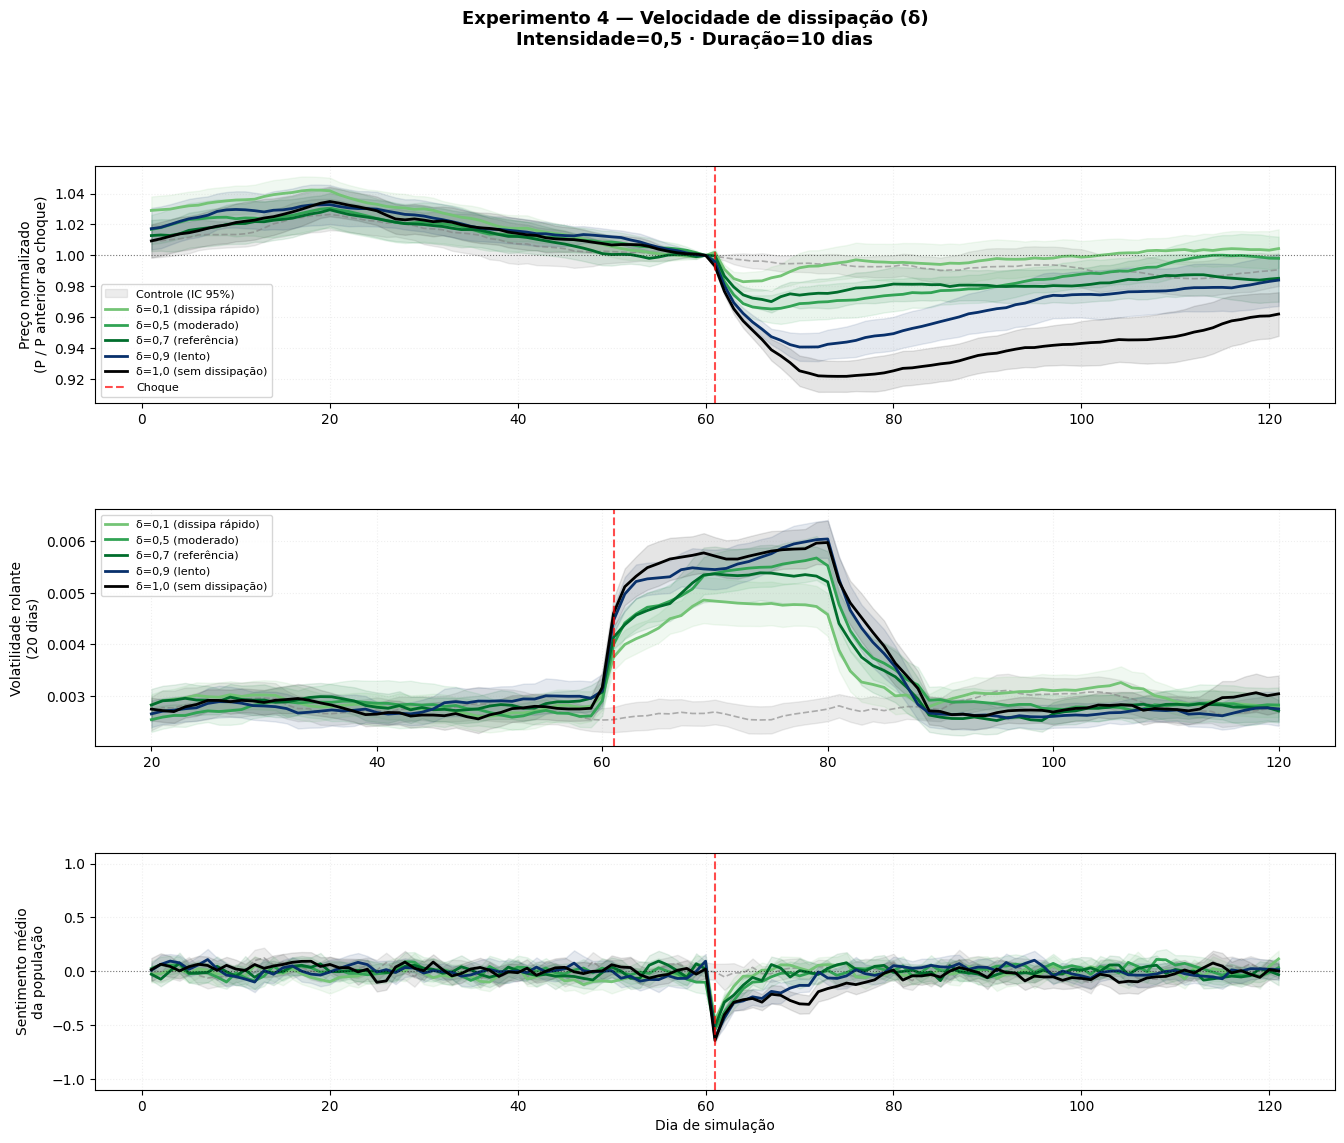

  ✓ Figura: /content/drive/MyDrive/tese_fii/choques/figures/exp4_delta.png

 Delta |  Queda máx (%) |  P̄ dias 100-121 (%) |   Pico vol | Dias vol>base |  Sent. mín
-------------------------------------------------------------------------------------
   0.1 |          -1.71 |                 0.29 |    0.00486 |            40 |    -0.2722
   0.5 |          -3.47 |                -0.44 |    0.00568 |            27 |    -0.3781
   0.7 |          -3.00 |                -1.48 |    0.00539 |            26 |    -0.2871
   0.9 |          -5.94 |                -2.15 |    0.00604 |            26 |    -0.4339
   1.0 |          -7.84 |                -4.86 |    0.00598 |            28 |    -0.4032


In [26]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO 4 — DELTA (velocidade de dissipação)
# ══════════════════════════════════════════════════════════════
print('\n── Experimento 4 — Delta (dissipação) ────────────────')

DELTAS = {
    0.1: 'δ=0,1 (dissipa rápido)',
    0.5: 'δ=0,5 (moderado)',
    0.7: 'δ=0,7 (referência)',
    0.9: 'δ=0,9 (lento)',
    1.0: 'δ=1,0 (sem dissipação)',
}
CORES_DLT = ['#74c476', '#31a354', '#006d2c', '#08306b', '#000000']

exp4     = []
t0_total = time.time()

for dlt, lbl in DELTAS.items():
    nome_cache = f'exp4_dlt_{str(dlt).replace(".", "_")}'
    resultado  = carregar(nome_cache)

    if resultado is None:
        t0 = time.time()
        c  = dict(tipo='negativo', intensidade=0.5,
                  duracao=10, delta=dlt, label=lbl)
        resultado = rodar_cenario_unico(c, 'exp4')
        salvar(resultado, nome_cache)
        print(f'    Tempo: {(time.time() - t0) / 60:.1f} min')

    exp4.append(resultado)

salvar(exp4, 'exp4_delta')
print(f'  Tempo total: {(time.time() - t0_total) / 60:.1f} min')

plot_experimento(
    exp4, controle_agg,
    titulo=('Experimento 4 — Velocidade de dissipação (δ)\n'
            'Intensidade=0,5 · Duração=10 dias'),
    fname='exp4_delta.png',
    cores=CORES_DLT,
)

# ── Tabela resumo Exp 4 ───────────────────────────────────────
print(f'\n{"Delta":>6} | {"Queda máx (%)":>14} | '
      f'{"P̄ dias 100-121 (%)":>20} | '
      f'{"Pico vol":>10} | {"Dias vol>base":>13} | '
      f'{"Sent. mín":>10}')
print('-' * 85)

for (agg, meta) in exp4:
    dlt     = meta['delta']
    p, v, s = agg[0], agg[3], agg[6]
    if p is None: continue
    p_pos     = p[DIA_CHOQUE:]
    queda_max = (p_pos.min() - 1.0) * 100
    p_final   = (p[-20:].mean() - 1.0) * 100
    v_pos_c   = v[DIA_CHOQUE:][~np.isnan(v[DIA_CHOQUE:])] if v is not None else np.array([])
    pico_vol  = v_pos_c.max() if len(v_pos_c) > 0 else np.nan
    dias_vol  = int(np.sum(v_pos_c > limiar)) if len(v_pos_c) > 0 else 0
    sent_min  = s[DIA_CHOQUE:].min() if s is not None else np.nan
    print(f'{dlt:>6} | {queda_max:>14.2f} | {p_final:>20.2f} | '
          f'{pico_vol:>10.5f} | {dias_vol:>13} | {sent_min:>10.4f}')

# Apendice

In [19]:
import numpy as np
import pandas as pd

DIA = DIA_CHOQUE - 1                     # índice do dia do choque
POS = slice(DIA, None)

cp, cp_lo, cp_hi = controle_agg[0], controle_agg[1], controle_agg[2]
cv, cv_hi        = controle_agg[3], controle_agg[5]
cs, cs_hi        = controle_agg[6], controle_agg[8]

vol_base = cv[20:DIA_CHOQUE]; vol_base = vol_base[~np.isnan(vol_base)].mean()
limiar   = vol_base * 1.10

se = lambda m, hi: (hi - m) / 1.96       # erro padrão a partir do IC95 superior

def arg_ext(x):                          # índice do maior |x| no pós-choque, ignorando NaN
    seg = x[POS]; idx = np.where(~np.isnan(seg))[0]
    return DIA + idx[np.argmax(np.abs(seg[idx]))]

def estat(agg):
    p, p_lo, p_hi = agg[0], agg[1], agg[2]
    v, v_hi       = agg[3], agg[5]
    s, s_hi       = agg[6], agg[8]

    dev_p = p - cp
    se_p  = np.sqrt(se(p, p_hi)**2 + se(cp, cp_hi)**2)
    ip    = arg_ext(dev_p)
    pfin  = np.nanmean(p[-20:] - cp[-20:]) * 100
    sig   = [t for t in range(DIA, len(p))
             if not (np.isnan(p_lo[t]) or np.isnan(cp_lo[t]))
             and (p_lo[t] > cp_hi[t] or p_hi[t] < cp_lo[t])]

    dev_s = s - cs
    se_s  = np.sqrt(se(s, s_hi)**2 + se(cs, cs_hi)**2)
    isx   = arg_ext(dev_s)

    dev_v = v - cv
    se_v  = np.sqrt(se(v, v_hi)**2 + se(cv, cv_hi)**2)
    iv    = arg_ext(dev_v)
    vabs  = v[POS][~np.isnan(v[POS])]

    return {
        'Preço pico (%)'    : f'{dev_p[ip]*100:+.2f} ± {1.96*se_p[ip]*100:.2f}',
        'Dia'               : ip,
        'P̄ final (%)'       : f'{pfin:+.2f}',
        'Signif. (dias)'    : f'{sig[0]}–{sig[-1]} ({len(sig)})' if sig else '—',
        'Sentimento'        : f'{dev_s[isx]:+.3f} ± {1.96*se_s[isx]:.3f}',
        'Vol. pico vs ctrl' : f'{dev_v[iv]:+.5f} ± {1.96*se_v[iv]:.5f}',
        'Dias vol>base'     : int(np.sum(vabs > limiar)),
    }

experimentos = [('Tipo', exp1), ('Intensidade', exp2),
                ('Duração', exp3), ('Dissipação', exp4)]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
for nome, exp in experimentos:
    df = pd.DataFrame({meta['label'].replace('\n', ' '): estat(agg)
                       for (agg, meta) in exp}).T
    print(f'\n===== {nome} =====')
    print(df.to_string())

# Teste de assimetria do Experimento 1 (pico do sentimento e do preço)
print('\n===== Assimetria Exp. 1 (|negativo| - |positivo|) =====')
def valse(agg, canal, dia):
    m, hi = agg[canal], agg[canal + 2]
    base = controle_agg[canal]; base_hi = controle_agg[canal + 2]
    d = m[dia] - base[dia]
    sed = np.sqrt(((hi[dia]-m[dia])/1.96)**2 + ((base_hi[dia]-base[dia])/1.96)**2)
    return d, sed
R = {meta['tipo']: agg for (agg, meta) in exp1}
for canal, nome in [(6, 'Sentimento (dia do choque)'), (0, 'Preço (pico)')]:
    dia = DIA if canal == 6 else arg_ext(R['negativo'][canal] - controle_agg[canal])
    dn, sn = valse(R['negativo'], canal, dia)
    dp, sp = valse(R['positivo'], canal, dia)
    dif = abs(dn) - abs(dp); ic = 1.96*np.sqrt(sn**2 + sp**2)
    signif = 'SIGNIFICATIVO' if abs(dif) > ic else 'dentro da margem'
    unid = '' if canal == 6 else ' (preço, unidade normalizada)'
    print(f'  {nome}: {dif:+.4f} ± {ic:.4f}{unid} -> {signif}')


===== Tipo =====
         Preço pico (%) Dia P̄ final (%) Signif. (dias)      Sentimento   Vol. pico vs ctrl Dias vol>base
Negativo   -2.06 ± 1.07  73        +0.44     61–76 (16)  -0.491 ± 0.079  +0.00184 ± 0.00034            36
Positivo   +3.21 ± 1.04  67        +1.48     61–85 (25)  +0.446 ± 0.083  +0.00264 ± 0.00050            21

===== Intensidade =====
                 Preço pico (%) Dia P̄ final (%) Signif. (dias)      Sentimento   Vol. pico vs ctrl Dias vol>base
Intensidade=0.1    -2.33 ± 0.97  66        -0.58     61–74 (14)  -0.437 ± 0.085  +0.00196 ± 0.00049            40
Intensidade=0.25   -2.57 ± 0.90  65        +0.06     61–82 (22)  -0.467 ± 0.087  +0.00214 ± 0.00047            22
Intensidade=0.5    -2.19 ± 0.72  65        -0.20     61–72 (12)  -0.520 ± 0.081  +0.00223 ± 0.00041            28
Intensidade=0.75   -2.84 ± 0.92  66        +0.18     61–76 (16)  -0.549 ± 0.077  +0.00249 ± 0.00044            23
Intensidade=0.95   -2.15 ± 1.15  72        +0.92     61–74 (14)  -0.5